<a href="https://colab.research.google.com/github/Nihat0311/Machine-Learning/blob/main/Ridge_Lasso_Elasticnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!curl -L -o autompg-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/uciml/autompg-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  6461  100  6461    0     0  16318      0 --:--:-- --:--:-- --:--:-- 60952


In [2]:
!unzip /content/autompg-dataset.zip

Archive:  /content/autompg-dataset.zip
  inflating: auto-mpg.csv            


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv('/content/auto-mpg.csv')


In [5]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [6]:
df['brand']=df['car name'].apply(lambda x : x.split()[0])

In [7]:
df=df.drop('car name',axis=1)

In [8]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [9]:
df['horsepower']=df['horsepower'].replace('?',np.nan)
df['horsepower']=df['horsepower'].astype(float)

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OneHotEncoder,PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression , Ridge , Lasso , ElasticNet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split,learning_curve

In [11]:
X=df.drop('mpg',axis=1)
y=df['mpg'].copy()

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [13]:
num_features=X_train.select_dtypes(include=[np.number]).columns
cat_features=X_train.select_dtypes(exclude=[np.number]).columns

In [14]:
from sklearn.linear_model import SGDRegressor

In [15]:
num_pipeline=Pipeline([
    ('impute', SimpleImputer(strategy='mean')),  # median mode
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scale', StandardScaler())

])

cat_pipeline=Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),  # most_frequent
    ('encode', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))

])

transformer=ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)

],remainder='passthrough') #drop

# estimator=LinearRegression()
estimator=SGDRegressor(
    loss='squared_error',
    penalty='l1',
    learning_rate='adaptive',
    eta0=0.001
)

full_pipeline=Pipeline([
    ('transformer', transformer),
    ('estimator',  estimator)

])

In [16]:
full_pipeline.fit(X_train,y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['brand'], dtype='object'))])),
                ('estimator',
                 SGDRegressor(eta0=0.001, learning_rate='adaptive',
                              penalty='l1'))])

In [17]:
full_pipeline.score(X_train,y_train),full_pipeline.score(X_test,y_test)

(0.8805317151369582, 0.8862379313924499)

In [18]:
def plot_learning_curve(model,X,y,title):
  train_sizes,train_score,val_score=learning_curve(
      model,
      X,
      y,
      cv=5,
      scoring='neg_mean_squared_error',
      shuffle=True,
      train_sizes=np.linspace(0.1,1.0,10),
      random_state=42

  )
  rmse_train=np.sqrt(-train_score.mean(axis=1))
  rsme_val=np.sqrt(-val_score.mean(axis=1))

  plt.figure(figsize=(10,8))
  plt.plot(train_sizes,rmse_train,color='red',label='Training')
  plt.plot(train_sizes,rsme_val,color='green',label='valiadation')
  plt.grid()
  plt.legend()
  plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


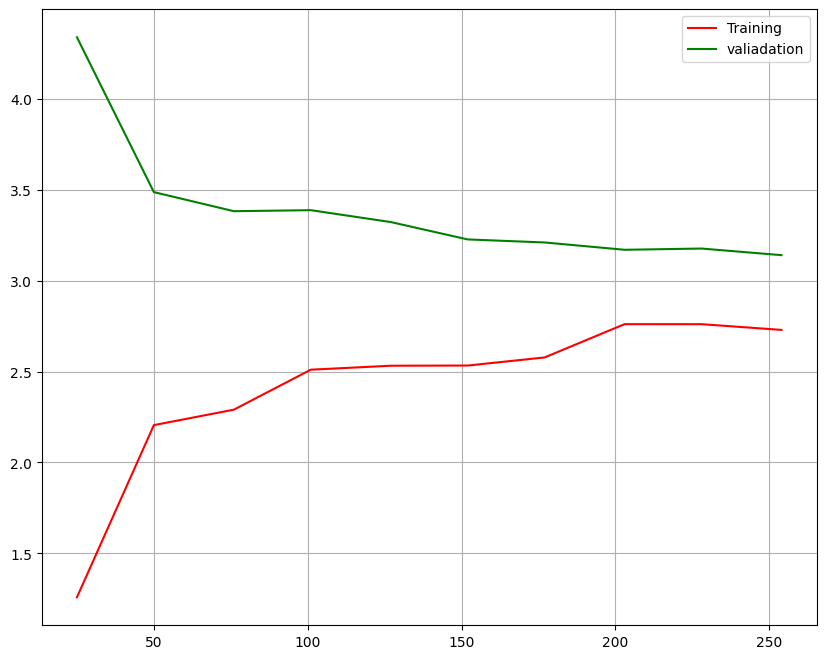

In [19]:
plot_learning_curve(full_pipeline,X_train,y_train,'Learning curve')

In [20]:
ridge_pipeline=Pipeline([
    ('transformer',transformer),
    ('estimator',Ridge(alpha=100.0))
])
ridge_pipeline.fit(X_train,y_train)
ridge_pipeline.score(X_train,y_train),ridge_pipeline.score(X_test,y_test)

(0.8394643213146503, 0.8794046173274335)

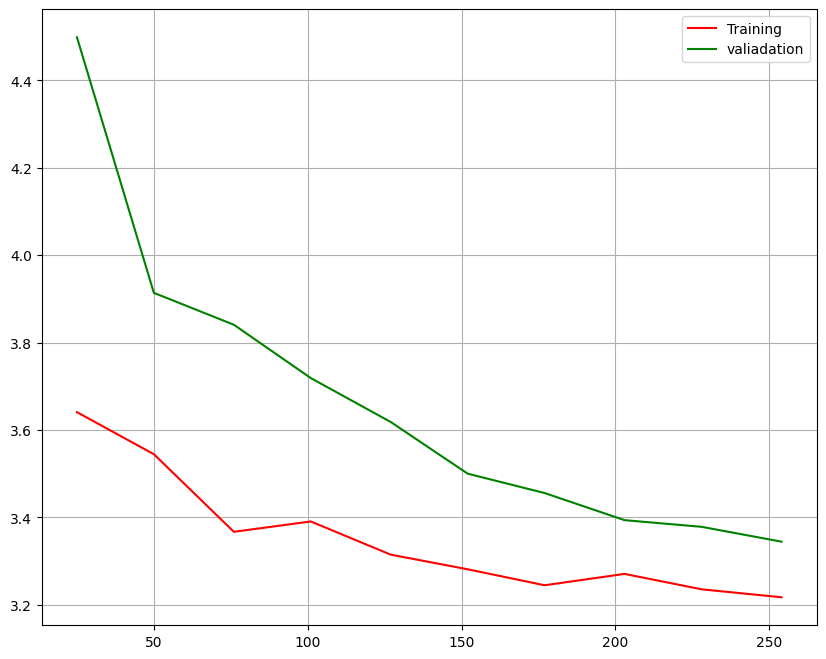

In [21]:
plot_learning_curve(ridge_pipeline,X_train,y_train,'Learning curve')

In [22]:
lasso_pipeline=Pipeline([
    ('transformer',transformer),
    ('estimator',Lasso(alpha=1.0))
])
lasso_pipeline.fit(X_train,y_train)
lasso_pipeline.score(X_train,y_train),lasso_pipeline.score(X_test,y_test)

(0.7972577125335975, 0.8523156357096535)

In [23]:
elastic_pipeline=Pipeline([
    ('transformer',transformer),
    ('estimator',ElasticNet(alpha=1.0,l1_ratio=0.5))
])
elastic_pipeline.fit(X_train,y_train)
elastic_pipeline.score(X_train,y_train),elastic_pipeline.score(X_test,y_test)

(0.7943891659271617, 0.8503214483059353)

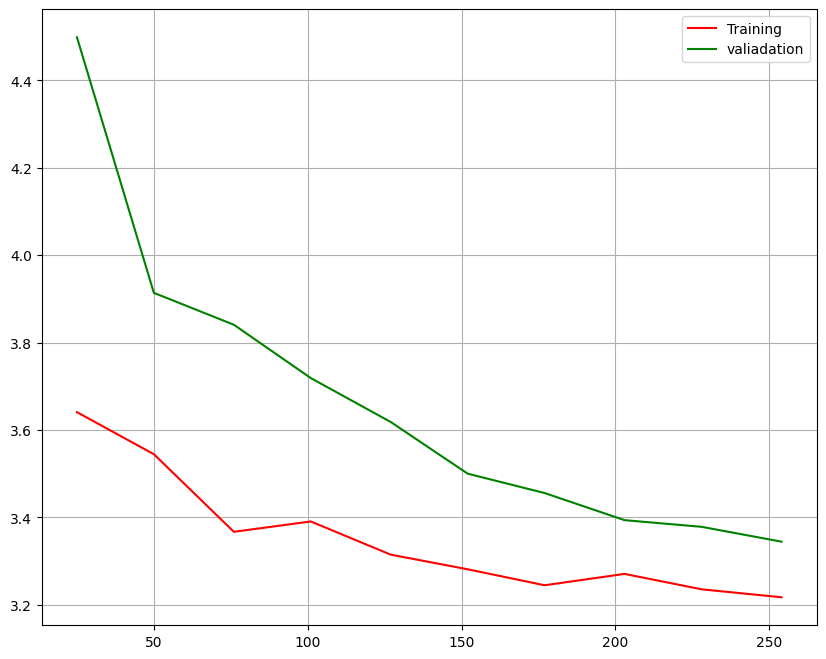

In [24]:
plot_learning_curve(ridge_pipeline,X_train,y_train,'Learning curve')

In [25]:
coef_pipeline=full_pipeline.named_steps['estimator'].coef_
coef_ridge=ridge_pipeline.named_steps['estimator'].coef_
coef_lasso=lasso_pipeline.named_steps['estimator'].coef_
coef_elasticnet=elastic_pipeline.named_steps['estimator'].coef_

In [26]:
feature_names =full_pipeline.named_steps['transformer'].get_feature_names_out()

coef_df=pd.DataFrame({
    "feature_names":feature_names,
    'coef_pipeline':coef_pipeline,
    "coef_ridge":coef_ridge,
    "coef_lasso":coef_lasso,
    "coef_elasticnet":coef_elasticnet,

})
coef_df

,feature_names,coef_pipeline,coef_ridge,coef_lasso,coef_elasticnet
0,num__cylinders,-0.331888,-0.147035,-0.00000,-0.188911
1,num__displacement,-0.873847,-0.247664,-0.00000,-0.264991
2,num__horsepower,-0.549681,-0.302106,-0.00000,-0.315795
3,num__weight,-1.182462,-0.664790,-3.61592,-0.690738
4,num__acceleration,-0.105128,0.136397,0.00000,0.000000
...,...,...,...,...,...
65,cat__brand_triumph,0.621987,0.055902,0.00000,0.000000
66,cat__brand_vokswagen,-0.317927,-0.037759,-0.00000,-0.000000
67,cat__brand_volkswagen,0.102378,-0.026782,0.00000,0.000000
68,cat__brand_volvo,0.333245,-0.048572,-0.00000,-0.000000


In [27]:
from sklearn.model_selection import cross_val_score

scores=cross_val_score(
    full_pipeline,
    X,
    y,
    scoring='neg_mean_squared_error',
    cv=5
)

rmse_score=np.sqrt(scores)

print('rmse',rmse_score)
print('avg rmse', rmse_score.mean())

rmse [nan nan nan nan nan]
avg rmse nan


/tmp/ipykernel_4328/239230923.py:11: RuntimeWarning: invalid value encountered in sqrt
  rmse_score=np.sqrt(scores)


In [28]:
from sklearn.model_selection import GridSearchCV

grid_params={
    "estimator__alpha":[0.1,1,10]
}

grid=GridSearchCV(ridge_pipeline,param_grid=grid_params,cv=5,scoring='neg_mean_squared_error')
grid.fit(X,y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer()),
                                                                                         ('poly',
                                                                                          PolynomialFeatures(include_bias=False)),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(fill_value='missing',
                                                                                                        strategy='constant')),
                                                                                         ('encode',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         Index(['brand'], dtype='object'))])),
                                       ('estimator', Ridge(alpha=100.0))]),
             param_grid={'estimator__alpha': [0.1, 1, 10]},
             scoring='neg_mean_squared_error')

In [29]:
grid.best_params_

{'estimator__alpha': 0.1}

In [30]:
grid.best_score_

np.float64(-10.701564640574206)

In [31]:
new_model=grid.best_estimator_
new_model

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['brand'], dtype='object'))])),
                ('estimator', Ridge(alpha=0.1))])

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_distribution={
    "estimator__alpha":loguniform(0.001,1000)
}
randomized=RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=param_distribution,
    cv=5,
    scoring='neg_mean_squared_error',
    n_iter=200)


randomized.fit(X,y)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('transformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer()),
                                                                                               ('poly',
                                                                                                PolynomialFeatures(include_bias=False)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='ob...
                                                                                                SimpleImputer(fill_value='missing',
                                                                                                              strategy='constant')),
                                                                                               ('encode',
                                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                                              sparse_output=False))]),
                                                                               Index(['brand'], dtype='object'))])),
                                             ('estimator',
                                              Ridge(alpha=100.0))]),
                   n_iter=200,
                   param_distributions={'estimator__alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e8431259a90>},
                   scoring='neg_mean_squared_error')

In [33]:
randomized.best_params_

{'estimator__alpha': np.float64(0.04691992756890911)}

In [34]:
randomized.best_score_

np.float64(-10.669195881834096)

In [35]:
randomized.best_estimator_

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['brand'], dtype='object'))])),
                ('estimator', Ridge(alpha=np.float64(0.04691992756890911)))])

In [36]:
X = np.array([[1.], [2.], [3.], [4.], [5.]])
y = np.array([[2.], [4.], [6.], [8.], [10.]])

w = np.zeros((1, 1))
lr = 0.1

In [37]:
for i in range(10):
    y_pred = X @ w
    gradient=(1/len(X)) * X.T @ (y_pred - y)
    w=w-lr*gradient
    print(f"stop : {i}, w :{w[0,0]:.3f}")

stop : 0, w :2.200
stop : 1, w :1.980
stop : 2, w :2.002
stop : 3, w :2.000
stop : 4, w :2.000
stop : 5, w :2.000
stop : 6, w :2.000
stop : 7, w :2.000
stop : 8, w :2.000
stop : 9, w :2.000


In [38]:
w=np.zeros((1,1))
for epoch in range(5):
  for i in range(len(X)):
    Xi=X[i:i+1]
    yi=y[i:i+1]

    y_pred=Xi@w
    gradient= Xi.T @ (y_pred - yi)
    w = w - lr * gradient
    print(f"step : {epoch},w :{w[0,0]:.3f}")

step : 0,w :0.200
step : 0,w :0.920
step : 0,w :1.892
step : 0,w :2.065
step : 0,w :1.903
step : 1,w :1.913
step : 1,w :1.948
step : 1,w :1.995
step : 1,w :2.003
step : 1,w :1.995
step : 2,w :1.996
step : 2,w :1.997
step : 2,w :2.000
step : 2,w :2.000
step : 2,w :2.000
step : 3,w :2.000
step : 3,w :2.000
step : 3,w :2.000
step : 3,w :2.000
step : 3,w :2.000
step : 4,w :2.000
step : 4,w :2.000
step : 4,w :2.000
step : 4,w :2.000
step : 4,w :2.000
